In [1]:
import pandas as pd
import numpy as np

In [2]:
movies = pd.read_csv('../data/movies (1).csv')
ratings = pd.read_csv('../data/ratings(1).csv')

In [3]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
final_dataset = ratings.pivot(index="movieId", columns="userId", values="rating")

In [6]:
final_dataset

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,NaN,NaN,4.0,NaN,4.5,NaN,NaN,NaN,...,4.0,NaN,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0,NaN,NaN,...,NaN,4.0,NaN,5.0,3.5,NaN,NaN,2.0,NaN,NaN
3,4.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
193583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
193585,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
final_dataset.fillna(0, inplace=True) #filling all nan with 0

In [8]:
#counting the ratings on movies, and users
no_user_voted = ratings.groupby("movieId")['rating'].agg('count')
no_movies_voted = ratings.groupby("userId")['rating'].agg('count')

In [9]:
no_user_voted #movies with their ratings

movieId
1         215
2         110
3          52
4           7
5          49
         ... 
193581      1
193583      1
193585      1
193587      1
193609      1
Name: rating, Length: 9724, dtype: int64

In [10]:
no_movies_voted #users and how many ratings they've made

userId
1       232
2        29
3        39
4       216
5        44
       ... 
606    1115
607     187
608     831
609      37
610    1302
Name: rating, Length: 610, dtype: int64

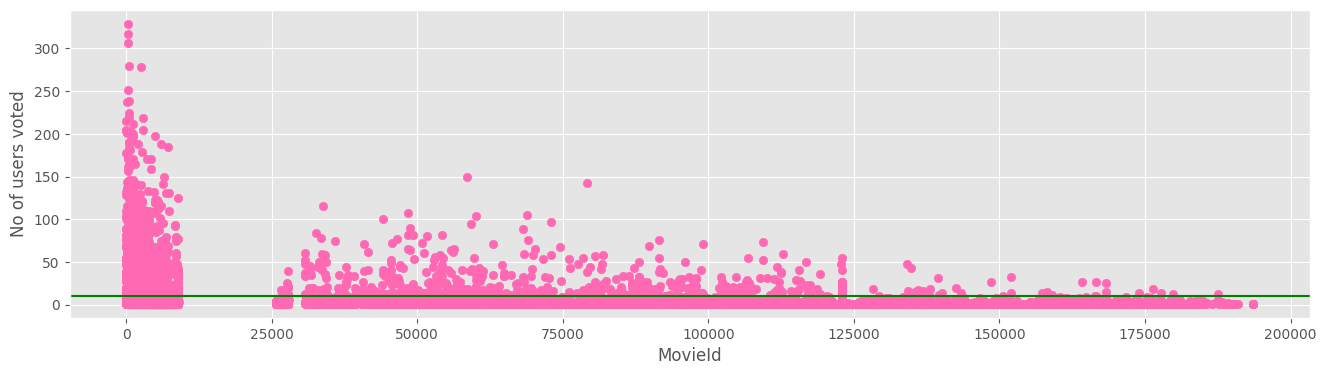

In [11]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")
fig,axes = plt.subplots(1,1, figsize=(16,4))
plt.scatter(no_user_voted.index, no_user_voted, color="hotpink")
plt.axhline(y=10, color='green')
plt.xlabel("MovieId")
plt.ylabel("No of users voted")
plt.show()

In [12]:
final_dataset = final_dataset.loc[no_user_voted[no_user_voted > 10].index, :] #all movies with ratings< 10 get dropped

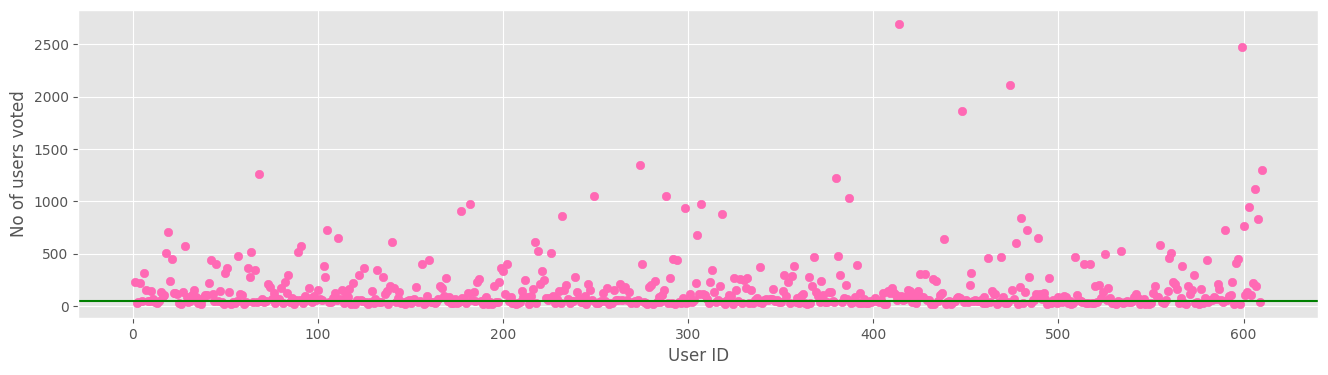

In [13]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")
fig,axes = plt.subplots(1,1, figsize=(16,4))
plt.scatter(no_movies_voted.index, no_movies_voted, color="hotpink")
plt.axhline(y=50, color='green')
plt.xlabel("User ID")
plt.ylabel("No of users voted")
plt.show()

In [14]:
final_dataset = final_dataset.loc[: , no_movies_voted[no_movies_voted>50].index] #all users whose rating<50 get dropped

In [15]:
final_dataset.shape

(2121, 378)

In [16]:
from scipy.sparse import csr_matrix

In [17]:
csr_data = csr_matrix(final_dataset.values) #storing only non-zero entries for movie ratings instead of noting all
final_dataset.reset_index(inplace=True) #entries because many users do not rate movies.

In [18]:
print(csr_data)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 72893 stored elements and shape (2121, 378)>
  Coords	Values
  (0, 0)	4.0
  (0, 3)	4.5
  (0, 6)	2.5
  (0, 8)	4.5
  (0, 9)	3.5
  (0, 10)	4.0
  (0, 12)	3.5
  (0, 16)	3.0
  (0, 19)	3.0
  (0, 20)	3.0
  (0, 25)	5.0
  (0, 28)	5.0
  (0, 29)	4.0
  (0, 31)	3.0
  (0, 34)	5.0
  (0, 38)	5.0
  (0, 39)	4.0
  (0, 40)	4.0
  (0, 41)	2.5
  (0, 43)	4.5
  (0, 46)	0.5
  (0, 47)	4.0
  (0, 50)	2.5
  (0, 53)	4.0
  (0, 55)	3.0
  :	:
  (2118, 205)	4.0
  (2118, 345)	1.5
  (2118, 357)	4.0
  (2118, 369)	4.5
  (2119, 37)	3.5
  (2119, 62)	3.0
  (2119, 98)	0.5
  (2119, 127)	4.5
  (2119, 156)	4.5
  (2119, 236)	0.5
  (2119, 256)	4.5
  (2119, 317)	2.0
  (2119, 345)	2.0
  (2119, 357)	5.0
  (2119, 365)	3.5
  (2120, 37)	4.0
  (2120, 62)	5.0
  (2120, 146)	2.5
  (2120, 155)	4.5
  (2120, 156)	5.0
  (2120, 186)	5.0
  (2120, 205)	4.0
  (2120, 236)	3.0
  (2120, 317)	3.5
  (2120, 357)	4.0


In [19]:
!pip install scikit-learn

In [20]:
from sklearn.model_selection import train_test_split
train_ratings, test_ratings = train_test_split(ratings, test_size=0.2, random_state=13)

In [21]:
from sklearn.neighbors import NearestNeighbors
knn = NearestNeighbors(metric='cosine', algorithm = 'brute', n_neighbors = 20, n_jobs = -1)
knn.fit(csr_data)

,n_neighbors,20
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,-1


In [22]:
def precision_at_k_knn_existing(k=10):
    knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=k+1, n_jobs=-1)
    knn.fit(csr_data)

    hits = 0
    total = 0

    movie_ids = final_dataset.index.tolist()

    for i in range(len(movie_ids)):
        movie_id = movie_ids[i]

        distances, indices = knn.kneighbors(csr_data[i], n_neighbors=k+1)
        neighbor_ids = [movie_ids[idx] for idx in indices.squeeze().tolist()[1:]]  # skip the movie itself

        # Get users who rated this movie
        actual_users = set(final_dataset.loc[movie_id][final_dataset.loc[movie_id] > 0].index)

        for neighbor_id in neighbor_ids:
            neighbor_users = set(final_dataset.loc[neighbor_id][final_dataset.loc[neighbor_id] > 0].index)
            common_users = actual_users.intersection(neighbor_users)
            hits += len(common_users)
            total += len(neighbor_users)

    precision = round(hits / total, 4) if total > 0 else 0
    print(f"Precision@{k} for KNN:", precision)

precision_at_k_knn_existing(k=10)
 # If a user liked one movie, see if they also liked movies similar to it; high KNN precision means the recommendations are accurate.

Precision@10 for KNN: 0.4637


In [23]:
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split
import pandas as pd

reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=0.2)

svd = SVD()
svd.fit(trainset)

In [24]:
def get_top_n_svd(user_id, n=10):
    movie_ids = ratings['movieId'].unique()
    
    rated_movies = ratings[ratings['userId'] == user_id]['movieId'].values
    
    unrated_movies = [mid for mid in movie_ids if mid not in rated_movies]

    predictions = [svd.predict(user_id, mid) for mid in unrated_movies]
    predictions.sort(key=lambda x: x.est, reverse=True)

    top_n = predictions[:n]
    recommended_titles = []
    for pred in top_n:
        title = movies[movies['movieId'] == pred.iid]['title'].values[0]
        recommended_titles.append({'Title': title, 'Predicted Rating': round(pred.est, 2)})

    return pd.DataFrame(recommended_titles)

    #Look at the movies the user hasn’t watched yet. Use what you know about the movies they have already rated 
   # (or how similar other users rated movies) to predict how much they would like each unwatched movie. 
    #    Recommend the top movies with the highest predicted rating.

In [25]:
get_top_n_svd(503) #predicting movies for user 503

,Title,Predicted Rating
0,Rear Window (1954),4.18
1,Snatch (2000),4.15
2,Chinatown (1974),4.14
3,"Great Escape, The (1963)",4.12
4,Casablanca (1942),4.11
5,North by Northwest (1959),4.06
6,Kiss Kiss Bang Bang (2005),4.05
7,Brazil (1985),4.05
8,"Boot, Das (Boat, The) (1981)",4.02
9,Dogville (2003),4.01


In [26]:
get_top_n_svd(113) #predicting movies for user 113

,Title,Predicted Rating
0,"Boondock Saints, The (2000)",4.68
1,Dr. Strangelove or: How I Learned to Stop Worr...,4.60
2,Kiss Kiss Bang Bang (2005),4.49
3,Eternal Sunshine of the Spotless Mind (2004),4.48
4,"Philadelphia Story, The (1940)",4.46
5,Rosemary's Baby (1968),4.44
6,Double Indemnity (1944),4.44
7,"Streetcar Named Desire, A (1951)",4.39
8,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.39
9,Lawrence of Arabia (1962),4.38


In [27]:
from surprise import accuracy
predictions = svd.test(testset)
print("RMSE:", accuracy.rmse(predictions))

RMSE: 0.8674
RMSE: 0.8673606063229118


In [28]:
def get_recommendation(movie_name):
    movie_list = movies[movies['title'].str.contains(movie_name)]
    if len(movie_list):
        movie_idx = movie_list.iloc[0]['movieId']
        movie_idx = final_dataset[final_dataset['movieId'] == movie_idx].index[0]
        distance, indices = knn.kneighbors(csr_data[movie_idx], n_neighbors=11)
        rec_movies_indices = sorted(list(zip(indices.squeeze().tolist(), distance.squeeze().tolist())), key=lambda x: x[1])[:0: -1]
        recommended_movies = []
        for val in rec_movies_indices:
            movie_idx = final_dataset.iloc[val[0]]['movieId']
            idx = movies[movies['movieId'] == movie_idx].index
            recommended_movies.append({'Title': movies.iloc[idx]['title'].values[0], 'Distance': val[1]})
        df = pd.DataFrame(recommended_movies, index=range(1, 11))
        return df
    else:
        return "Movie not found..."

In [29]:
get_recommendation('Toy Story')

,Title,Distance
1,Groundhog Day (1993),0.399495
2,"Lion King, The (1994)",0.398578
3,Pulp Fiction (1994),0.398293
4,Star Wars: Episode VI - Return of the Jedi (1983),0.390663
5,Apollo 13 (1995),0.384633
6,Shrek (2001),0.381472
7,Star Wars: Episode IV - A New Hope (1977),0.380789
8,Toy Story 2 (1999),0.371637
9,Forrest Gump (1994),0.356542
10,Jurassic Park (1993),0.334884


In [30]:
get_recommendation('Harry Potter')

,Title,Distance
1,"Lord of the Rings: The Two Towers, The (2002)",0.391128
2,"Incredibles, The (2004)",0.386104
3,Spider-Man (2002),0.379973
4,Star Wars: Episode II - Attack of the Clones (...,0.377116
5,Pirates of the Caribbean: The Curse of the Bla...,0.367811
6,"Monsters, Inc. (2001)",0.363530
7,Shrek (2001),0.342930
8,Harry Potter and the Goblet of Fire (2005),0.284509
9,Harry Potter and the Prisoner of Azkaban (2004),0.271120
10,Harry Potter and the Chamber of Secrets (2002),0.196221


In [31]:
import gradio as gr

def recommend_movies_advanced(movie_name_or_userid, method="KNN"):
    if method == "KNN":
        df = get_recommendation(movie_name_or_userid)
    else:  # method == "SVD"
        try:
            user_id = int(movie_name_or_userid)
            df = get_top_n_svd(user_id)
        except:
            return "For SVD, please enter a valid numeric User ID."
    
    if isinstance(df, pd.DataFrame):
        return df.to_string(index=False)
    else:
        return df

app = gr.Interface(
    fn=recommend_movies_advanced,
    inputs=[
        gr.Textbox(label="Movie name (KNN) or User ID (SVD)"),
        gr.Radio(choices=["KNN", "SVD"], label="Recommendation Method")
    ],
    outputs="text",
    title="Movie Recommendation System (KNN & SVD)",
    description="Enter a movie name for KNN or user ID for SVD-based recommendations"
)

app.launch(share=True)

/opt/miniconda3/envs/recommender/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://1c452b5a34e7fd9ece.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
